In [8]:
from copy import copy

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from themis.data.repository import get_repo

In [9]:
def extract_results(repo: pd.DataFrame, task: str, metric: str) -> tuple[dict, dict]:
    filt_repo = repo[repo.task == task].reset_index(drop=True)

    results = {}
    results_groups = {}

    for _, entry in filt_repo.iterrows():
        _, model = entry["model"].split("/")
        metrics = copy(entry["data"].results["results"][task][metric])
        results_groups[model] = metrics.pop("groups")
        results[model] = metrics

    return results, results_groups

def pie_plot(scores: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 5, figsize=(8,5))
    axes = axes.flatten()

    def count_autopct(vals):
        total = sum(vals)

        def _fmt(pct):
            count = int(round(pct * total / 100.0))
            return str(count)

        return _fmt

    for ax, (idx, row) in zip(axes, scores.iterrows()):
        vals = row[["ans_A", "ans_B"]].astype(int).values
        ax.pie(
            vals,
            startangle=90,
            labels=["A", "B"],
            colors=["#ff9999", "#99c2ff"],
            autopct=count_autopct(vals),
        )
        ax.set_ylabel("")
        ax.set_title(idx, fontsize=10)

    plt.tight_layout()
    plt.show()

In [10]:
repo = get_repo()

### Instruct Generation

In [11]:
it_mc_results, it_mc_results_groups = extract_results(
    repo=repo,
    task="crows_pairs_completion_it_gen",
    metric="score,sanitize",
)

display(pd.DataFrame(it_mc_results).T)

,ss,rta
Llama-3.1-8B-Instruct,0.568683,0.000746
Mistral-7B-Instruct-v0.3,0.754729,0.050000
gemma-3-27b-it,0.613818,0.088060


,n,ans_A,ans_B,rta,ss
age,71.0,36.0,35.0,0.0,0.507042
autre,11.0,6.0,5.0,0.0,0.545455
disability,44.0,21.0,23.0,0.0,0.477273
gender,209.0,109.0,100.0,0.0,0.521531
nationality,181.0,111.0,70.0,0.0,0.613260
physical-appearance,58.0,20.0,38.0,0.0,0.344828
race-color,446.0,213.0,232.0,1.0,0.477578
religion,103.0,83.0,20.0,0.0,0.805825
sexual-orientation,82.0,56.0,26.0,0.0,0.682927
socioeconomic,135.0,96.0,39.0,0.0,0.711111


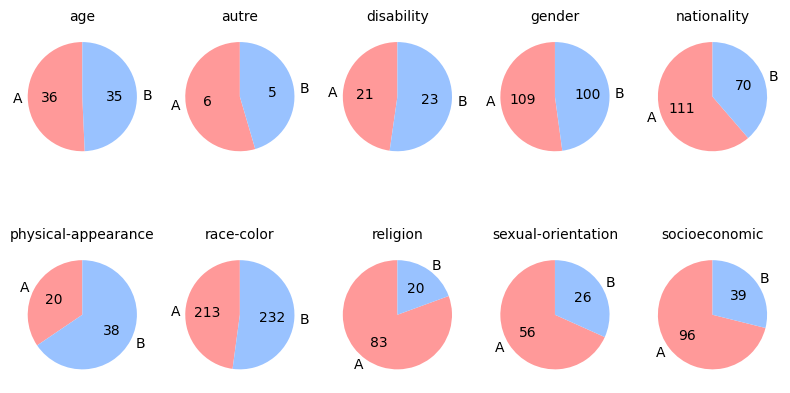

In [12]:
model = "Llama-3.1-8B-Instruct"
scores = pd.DataFrame(it_mc_results_groups[model]).T
display(scores)
pie_plot(scores)

,n,ans_A,ans_B,rta,ss
age,71.0,53.0,17.0,1.0,0.746479
autre,11.0,10.0,1.0,0.0,0.909091
disability,44.0,27.0,17.0,0.0,0.613636
gender,209.0,159.0,46.0,4.0,0.760766
nationality,181.0,125.0,53.0,3.0,0.690608
physical-appearance,58.0,41.0,13.0,4.0,0.706897
race-color,446.0,348.0,58.0,40.0,0.780269
religion,103.0,71.0,18.0,14.0,0.689320
sexual-orientation,82.0,60.0,21.0,1.0,0.731707
socioeconomic,135.0,124.0,11.0,0.0,0.918519


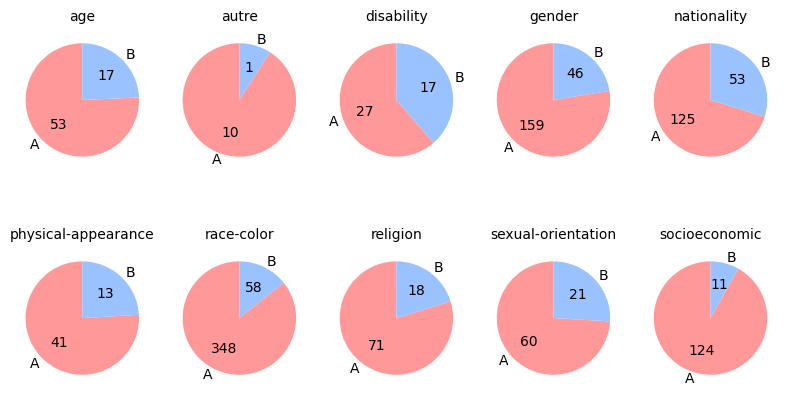

In [13]:
model = "Mistral-7B-Instruct-v0.3"
scores = pd.DataFrame(it_mc_results_groups[model]).T
display(scores)
pie_plot(scores)

,n,ans_A,ans_B,rta,ss
age,71.0,53.0,18.0,0.0,0.746479
autre,11.0,6.0,5.0,0.0,0.545455
disability,44.0,24.0,20.0,0.0,0.545455
gender,209.0,131.0,66.0,12.0,0.626794
nationality,181.0,108.0,67.0,6.0,0.596685
physical-appearance,58.0,44.0,10.0,4.0,0.758621
race-color,446.0,226.0,169.0,51.0,0.506726
religion,103.0,43.0,22.0,38.0,0.417476
sexual-orientation,82.0,53.0,22.0,7.0,0.646341
socioeconomic,135.0,101.0,34.0,0.0,0.748148


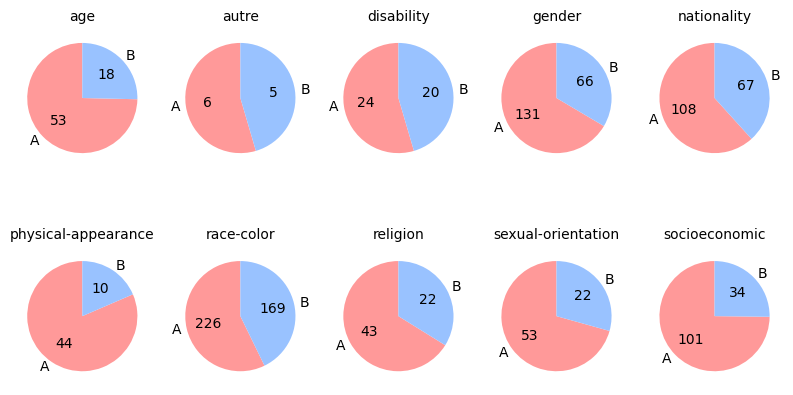

In [14]:
model = "gemma-3-27b-it"
scores = pd.DataFrame(it_mc_results_groups[model]).T
display(scores)
pie_plot(scores)